In [1]:
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder

import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from spacy.lang.en.stop_words import STOP_WORDS as en_stop
from nltk import word_tokenize          

from gensim.models import Word2Vec

In [2]:
class GenreClassifier(nn.Module):
    def __init__(self, input_dim,hidden_dim, num_classes=6):
        super(GenreClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes) 
        self.relu = nn.ReLU()  

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x
    


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        """
        patience: Nombre d'époques à attendre avant d'arrêter si pas d'amélioration.
        min_delta: Amélioration minimale considérée comme significative.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0 
        else:
            self.counter += 1 
        return self.counter >= self.patience


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
def train(dataloader,model,loss_fnc,optimizer,epoch):
    model.train()
    for batch_size,(X,y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = loss_fnc(y_pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(f"Step: {epoch} Train Loss: {loss.item():.4f}")
    return loss


def test(dataloader,model,loss_fnc,encoder):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        X_test = torch.cat([X for X, _ in dataloader], dim=0)
        y_test = torch.cat([y for _, y in dataloader], dim=0)
        X_test = X_test.to(device)
        y_test = y_test.to(device)
        y_pred = model(X_test)
        test_loss += loss_fnc(y_pred, y_test).item()

    y_test = y_test.cpu().numpy()
    y_pred = torch.argmax(y_pred, dim=1).cpu().numpy()

    print(f"Classification Report:\n", classification_report(encoder.inverse_transform(y_test), encoder.inverse_transform(y_pred)))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


# Processing data

In [5]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.2
random_state = 42

In [6]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)


C:\Users\letru\AppData\Local\Temp\ipykernel_16724\2146986483.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


# Training and test

In [7]:
X_train,X_test , y_train,y_test = train_test_split(df_movies['Script'],df_movies['filtered_genre'],test_size=test_size,random_state=random_state)

In [9]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def preprocess(script):
    tokens = word_tokenize(script.lower())
    filtered = [token for token in tokens if token.isalpha() and token not in stop_words]
    return filtered

X_train_token = [preprocess(script) for script in X_train]
X_test_token = [preprocess(script) for script in X_test]

In [10]:
word2vec = Word2Vec(sentences=X_train_token, vector_size=300, window=5, min_count=2, workers=4)

In [11]:
def vectorize_sentence(sentence, model):
    """Retourne la moyenne des vecteurs des mots d'une phrase"""
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)


X_train_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_train_token])
X_test_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_test_token])

In [12]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_tensor_train = torch.tensor(X_train_vectors,dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_vectors,dtype=torch.float32)
y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)



In [13]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [14]:
model = GenreClassifier(X_train_vectors.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 0.7740
Step: 100 Train Loss: 0.3828
Step: 200 Train Loss: 0.3448
Step: 300 Train Loss: 0.3177
Step: 400 Train Loss: 0.3028
Step: 500 Train Loss: 0.2945
Step: 600 Train Loss: 0.2892
Early stopping triggered at epoch 698 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.66      0.85      0.74       314
imdb_documentary       0.90      0.85      0.87       251
      imdb_drama       0.78      0.78      0.78       609
     imdb_horror       0.83      0.75      0.79       171
    imdb_romance       0.67      0.52      0.59        61
   imdb_thriller       0.75      0.50      0.60       138

        accuracy                           0.77      1544
       macro avg       0.76      0.71      0.73      1544
    weighted avg       0.77      0.77      0.77      1544



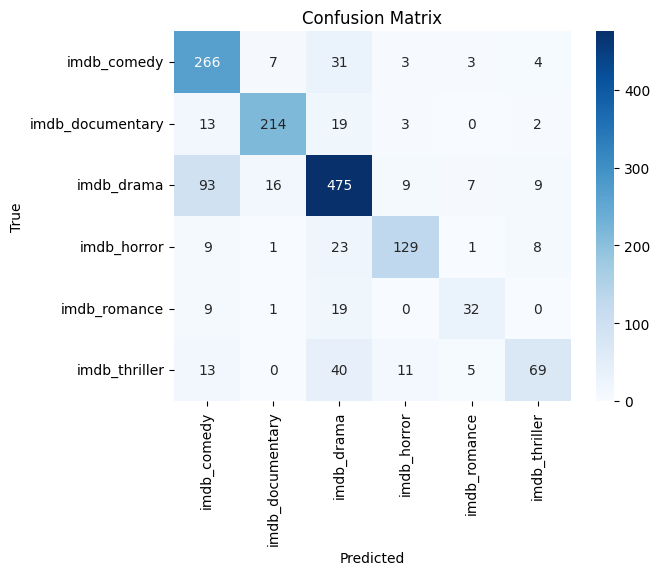

In [15]:
test(dataloader_test,model,loss_fnc,encoder)

# TF-IDF

In [18]:
X_train_preprocessed = [" ".join(tokens) for tokens in X_train_token]
X_test_preprocessed = [" ".join(tokens) for tokens in X_test_token]


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train_preprocessed)
X_test_tfidf = vectorizer.transform(X_test_preprocessed)

In [22]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_train_dense = X_train_tfidf.toarray() 
X_test_dense = X_test_tfidf.toarray() 
X_tensor_train = torch.tensor(X_train_dense, dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_dense, dtype=torch.float32)

# Encoder les labels (ça a l'air déjà fait dans ton code)
y_tensor_train = torch.tensor(y_train_encoded, dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded, dtype=torch.long).view(-1)

In [23]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [25]:
model = GenreClassifier(X_train_dense.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 0.9151
Step: 100 Train Loss: 0.0442
Step: 200 Train Loss: 0.0136
Step: 300 Train Loss: 0.0278
Early stopping triggered at epoch 315 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.60      0.72      0.66       314
imdb_documentary       0.77      0.88      0.82       251
      imdb_drama       0.74      0.61      0.67       609
     imdb_horror       0.66      0.70      0.68       171
    imdb_romance       0.60      0.52      0.56        61
   imdb_thriller       0.43      0.43      0.43       138

        accuracy                           0.67      1544
       macro avg       0.63      0.64      0.64      1544
    weighted avg       0.67      0.67      0.67      1544



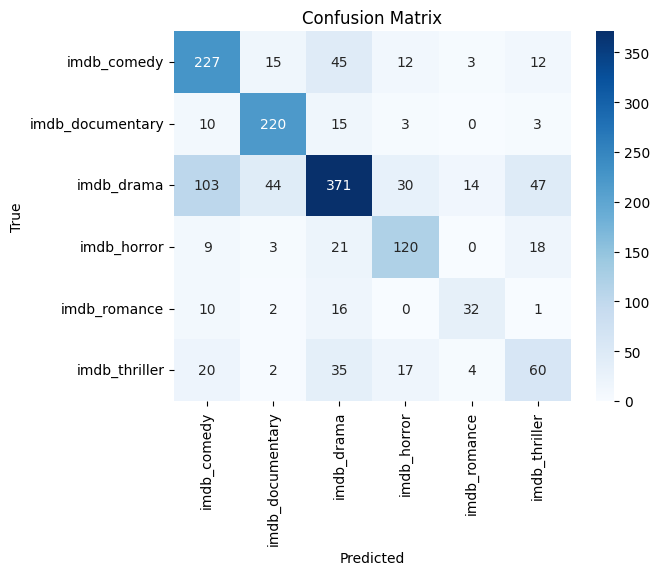

In [26]:
test(dataloader_test,model,loss_fnc,encoder)

# Data augmentation

In [6]:
import pandas as pd
import random
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /home/pierre/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/pierre/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/pierre/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/pierre/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/pierre/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [7]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.2
random_state = 42

In [8]:
df = pd.read_csv("../../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies= df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)

/tmp/ipykernel_897/1532818558.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


In [9]:
X_train, X_test , y_train,y_test = train_test_split(df_movies['Script'],df_movies['filtered_genre'],test_size=test_size,random_state=random_state)

In [10]:
len(X_train)

6176

## Synonym

In [10]:
# Perform augmentation
stop_words = set(stopwords.words("english"))

# Mapping NLTK POS → WordNet POS
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

def get_synonym(word, tag):
    wn_tag = get_wordnet_pos(tag)
    if wn_tag is None:
        return word

    synsets = wordnet.synsets(word, pos=wn_tag)
    if not synsets:
        return word

    lemmas = [lemma.name().replace("_", " ") for syn in synsets for lemma in syn.lemmas()
              if lemma.name().lower() != word.lower()]
    return random.choice(lemmas) if lemmas else word

def synonym_augment(text):
    words = word_tokenize(text)
    tagged_words = nltk.pos_tag(words)
    new_words = []

    for word, tag in tagged_words:
        if word.lower() not in stop_words and word.isalpha():
            synonym = get_synonym(word, tag)
            new_words.append(synonym)
        else:
            new_words.append(word)

    return ' '.join(new_words)

# Augment underrepresented genres
thriller_romance_indices = y_train[(y_train == 'imdb_thriller') | (y_train == 'imdb_romance')].index
thriller_romance_script = X_train.loc[thriller_romance_indices].apply(synonym_augment)

X_train = pd.concat([X_train, thriller_romance_script], ignore_index=True)
y_train = pd.concat([y_train, y_train.loc[thriller_romance_indices]], ignore_index=True)


In [11]:
len(X_train)

6882

In [12]:
X_train_token = [word_tokenize(script) for script in X_train]
X_test_token = [word_tokenize(script) for script in X_test]

In [13]:
word2vec = Word2Vec(sentences=X_train_token, vector_size=300, window=5, min_count=2, workers=4)

In [14]:
def vectorize_sentence(sentence, model):
    """Retourne la moyenne des vecteurs des mots d'une phrase"""
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)


X_train_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_train_token])
X_test_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_test_token])

In [15]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_tensor_train = torch.tensor(X_train_vectors,dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_vectors,dtype=torch.float32)
y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)



In [16]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [17]:
model = GenreClassifier(X_train_vectors.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 0.5905
Step: 100 Train Loss: 0.1189
Early stopping triggered at epoch 163 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.83      0.45      0.58       314
imdb_documentary       0.91      0.85      0.88       251
      imdb_drama       0.56      0.97      0.71       609
     imdb_horror       0.96      0.13      0.23       171
    imdb_romance       0.84      0.43      0.57        61
   imdb_thriller       0.60      0.17      0.27       138

        accuracy                           0.66      1544
       macro avg       0.78      0.50      0.54      1544
    weighted avg       0.73      0.66      0.61      1544



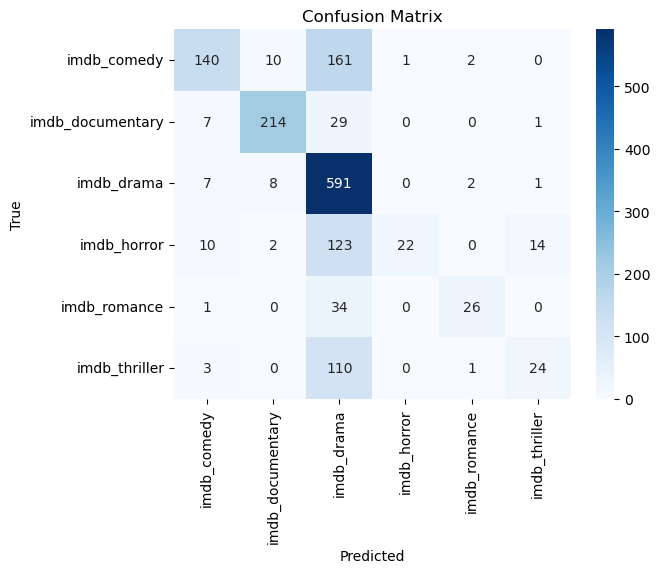

In [18]:
test(dataloader_test,model,loss_fnc,encoder)

## Random Insertion

In [12]:
def random_insertion(text, n=100):
    words = word_tokenize(text)
    new_words = words.copy()
    for _ in range(n):
        word = random.choice(new_words)
        syns = wordnet.synsets(word)
        if syns:
            synonym = syns[0].lemmas()[0].name()
            idx = random.randint(0, len(new_words)-1)
            new_words.insert(idx, synonym)
    return ' '.join(new_words)

# Augment underrepresented genres
thriller_romance_indices = y_train[(y_train == 'imdb_thriller') | (y_train == 'imdb_romance')].index
thriller_romance_script = X_train.loc[thriller_romance_indices].apply(random_insertion)

X_train = pd.concat([X_train, thriller_romance_script], ignore_index=True)
y_train = pd.concat([y_train, y_train.loc[thriller_romance_indices]], ignore_index=True)


In [13]:
len(X_train)

6882

In [14]:
X_train_token = [word_tokenize(script) for script in X_train]
X_test_token = [word_tokenize(script) for script in X_test]

In [15]:
word2vec = Word2Vec(sentences=X_train_token, vector_size=300, window=5, min_count=2, workers=4)

In [16]:
def vectorize_sentence(sentence, model):
    """Retourne la moyenne des vecteurs des mots d'une phrase"""
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)


X_train_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_train_token])
X_test_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_test_token])

In [17]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_tensor_train = torch.tensor(X_train_vectors,dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_vectors,dtype=torch.float32)
y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)

In [18]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [19]:
model = GenreClassifier(X_train_vectors.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 0.5641
Step: 100 Train Loss: 0.1667
Early stopping triggered at epoch 166 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.84      0.31      0.45       314
imdb_documentary       0.81      0.90      0.85       251
      imdb_drama       0.88      0.11      0.19       609
     imdb_horror       0.68      0.26      0.38       171
    imdb_romance       0.31      0.70      0.43        61
   imdb_thriller       0.15      0.96      0.26       138

        accuracy                           0.39      1544
       macro avg       0.61      0.54      0.43      1544
    weighted avg       0.75      0.39      0.39      1544



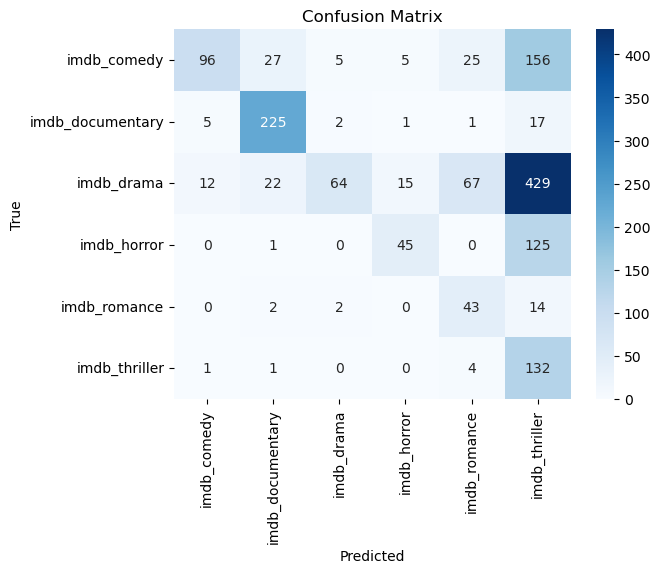

: 

In [ ]:
test(dataloader_test,model,loss_fnc,encoder)

## Sentence Shuffle

In [11]:
import random
from nltk.tokenize import sent_tokenize

def sentence_shuffle(text, shuffle_ratio=0.5):
    sentences = sent_tokenize(text)
    n = int(len(sentences) * shuffle_ratio)
    
    indices = list(range(len(sentences)))
    to_shuffle = random.sample(indices, n)
    
    shuffled = sentences.copy()
    shuffled_subset = [sentences[i] for i in to_shuffle]
    random.shuffle(shuffled_subset)
    
    for i, idx in enumerate(to_shuffle):
        shuffled[idx] = shuffled_subset[i]
    
    return ' '.join(shuffled)

# Augment underrepresented genres
thriller_romance_indices = y_train[(y_train == 'imdb_thriller') | (y_train == 'imdb_romance')].index
thriller_romance_script = X_train.loc[thriller_romance_indices].apply(sentence_shuffle)

X_train = pd.concat([X_train, thriller_romance_script], ignore_index=True)
y_train = pd.concat([y_train, y_train.loc[thriller_romance_indices]], ignore_index=True)


In [12]:
len(X_train)

6882

In [13]:
X_train_token = [word_tokenize(script) for script in X_train]
X_test_token = [word_tokenize(script) for script in X_test]

In [14]:
word2vec = Word2Vec(sentences=X_train_token, vector_size=300, window=5, min_count=2, workers=4)

In [15]:
def vectorize_sentence(sentence, model):
    """Retourne la moyenne des vecteurs des mots d'une phrase"""
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)


X_train_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_train_token])
X_test_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_test_token])

In [16]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_tensor_train = torch.tensor(X_train_vectors,dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_vectors,dtype=torch.float32)
y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)

In [17]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [18]:
model = GenreClassifier(X_train_vectors.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 0.5660
Step: 100 Train Loss: 0.1629
Early stopping triggered at epoch 190 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.69      0.61      0.64       314
imdb_documentary       0.95      0.83      0.88       251
      imdb_drama       0.89      0.05      0.10       609
     imdb_horror       0.77      0.19      0.31       171
    imdb_romance       0.34      0.70      0.46        61
   imdb_thriller       0.16      0.95      0.27       138

        accuracy                           0.41      1544
       macro avg       0.63      0.56      0.44      1544
    weighted avg       0.76      0.41      0.39      1544



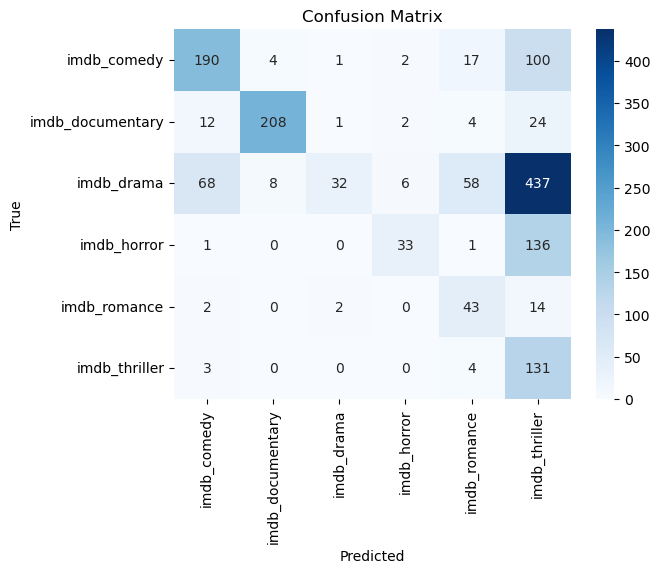

In [19]:
test(dataloader_test,model,loss_fnc,encoder)

# TF-IDF

## Synonym

In [19]:
X_train_preprocessed = [" ".join(tokens) for tokens in X_train_token]
X_test_preprocessed = [" ".join(tokens) for tokens in X_test_token]


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train_preprocessed)
X_test_tfidf = vectorizer.transform(X_test_preprocessed)

In [21]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_train_dense = X_train_tfidf.toarray() 
X_test_dense = X_test_tfidf.toarray() 
X_tensor_train = torch.tensor(X_train_dense, dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_dense, dtype=torch.float32)

# Encoder les labels (ça a l'air déjà fait dans ton code)
y_tensor_train = torch.tensor(y_train_encoded, dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded, dtype=torch.long).view(-1)

In [22]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [23]:
model = GenreClassifier(X_train_dense.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 1.2100
Step: 100 Train Loss: 0.0118
Step: 200 Train Loss: 0.0008
Early stopping triggered at epoch 220 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.71      0.62      0.66       314
imdb_documentary       0.79      0.86      0.83       251
      imdb_drama       0.74      0.72      0.73       609
     imdb_horror       0.66      0.71      0.69       171
    imdb_romance       0.62      0.49      0.55        61
   imdb_thriller       0.40      0.50      0.45       138

        accuracy                           0.69      1544
       macro avg       0.66      0.65      0.65      1544
    weighted avg       0.70      0.69      0.70      1544



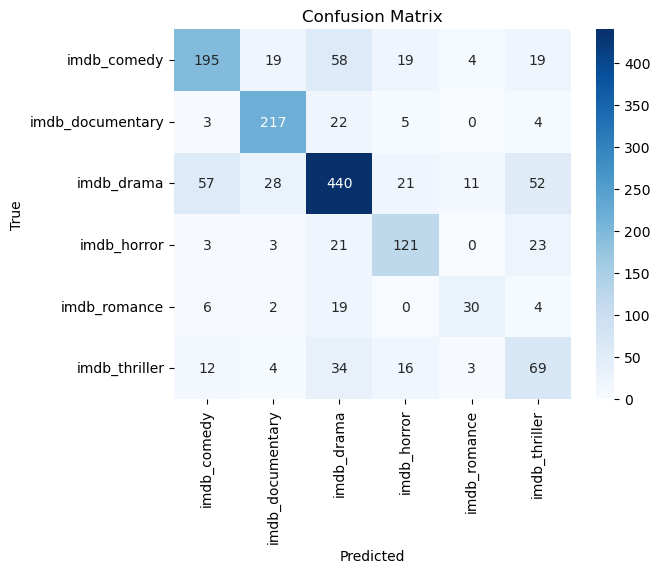

In [ ]:
test(dataloader_test,model,loss_fnc,encoder)

## Random Insertion

In [10]:
def random_insertion(text, n=100):
    words = word_tokenize(text)
    new_words = words.copy()
    for _ in range(n):
        word = random.choice(new_words)
        syns = wordnet.synsets(word)
        if syns:
            synonym = syns[0].lemmas()[0].name()
            idx = random.randint(0, len(new_words)-1)
            new_words.insert(idx, synonym)
    return ' '.join(new_words)

# Augment underrepresented genres
thriller_romance_indices = y_train[(y_train == 'imdb_thriller') | (y_train == 'imdb_romance')].index
thriller_romance_script = X_train.loc[thriller_romance_indices].apply(random_insertion)

X_train = pd.concat([X_train, thriller_romance_script], ignore_index=True)
y_train = pd.concat([y_train, y_train.loc[thriller_romance_indices]], ignore_index=True)


In [11]:
len(X_train)

6882

In [13]:
X_train_token = [word_tokenize(script) for script in X_train]
X_test_token = [word_tokenize(script) for script in X_test]

In [14]:
X_train_preprocessed = [" ".join(tokens) for tokens in X_train_token]
X_test_preprocessed = [" ".join(tokens) for tokens in X_test_token]

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train_preprocessed)
X_test_tfidf = vectorizer.transform(X_test_preprocessed)

In [16]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_train_dense = X_train_tfidf.toarray() 
X_test_dense = X_test_tfidf.toarray() 
X_tensor_train = torch.tensor(X_train_dense, dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_dense, dtype=torch.float32)

# Encoder les labels (ça a l'air déjà fait dans ton code)
y_tensor_train = torch.tensor(y_train_encoded, dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded, dtype=torch.long).view(-1)

In [17]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [18]:
model = GenreClassifier(X_train_dense.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 1.0002
Step: 100 Train Loss: 0.0054
Step: 200 Train Loss: 0.0019
Early stopping triggered at epoch 230 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.69      0.66      0.68       314
imdb_documentary       0.88      0.82      0.85       251
      imdb_drama       0.76      0.67      0.71       609
     imdb_horror       0.65      0.65      0.65       171
    imdb_romance       0.67      0.46      0.54        61
   imdb_thriller       0.32      0.61      0.42       138

        accuracy                           0.68      1544
       macro avg       0.66      0.64      0.64      1544
    weighted avg       0.71      0.68      0.69      1544



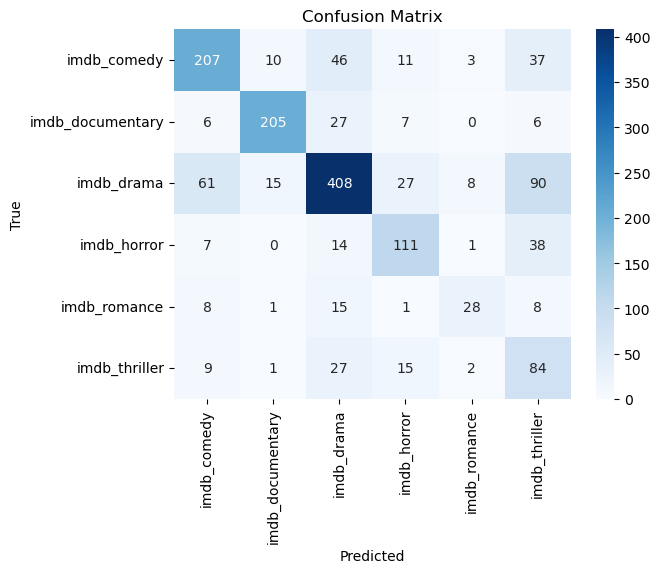

In [19]:
test(dataloader_test,model,loss_fnc,encoder)

## Sentence Shuffle

In [11]:
import random
from nltk.tokenize import sent_tokenize

def sentence_shuffle(text, shuffle_ratio=0.5):
    sentences = sent_tokenize(text)
    n = int(len(sentences) * shuffle_ratio)
    
    indices = list(range(len(sentences)))
    to_shuffle = random.sample(indices, n)
    
    shuffled = sentences.copy()
    shuffled_subset = [sentences[i] for i in to_shuffle]
    random.shuffle(shuffled_subset)
    
    for i, idx in enumerate(to_shuffle):
        shuffled[idx] = shuffled_subset[i]
    
    return ' '.join(shuffled)

# Augment underrepresented genres
thriller_romance_indices = y_train[(y_train == 'imdb_thriller') | (y_train == 'imdb_romance')].index
thriller_romance_script = X_train.loc[thriller_romance_indices].apply(sentence_shuffle)

X_train = pd.concat([X_train, thriller_romance_script], ignore_index=True)
y_train = pd.concat([y_train, y_train.loc[thriller_romance_indices]], ignore_index=True)


In [12]:
len(X_train)

6882

In [13]:
X_train_token = [word_tokenize(script) for script in X_train]
X_test_token = [word_tokenize(script) for script in X_test]

In [14]:
X_train_preprocessed = [" ".join(tokens) for tokens in X_train_token]
X_test_preprocessed = [" ".join(tokens) for tokens in X_test_token]

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train_preprocessed)
X_test_tfidf = vectorizer.transform(X_test_preprocessed)

In [16]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_train_dense = X_train_tfidf.toarray() 
X_test_dense = X_test_tfidf.toarray() 
X_tensor_train = torch.tensor(X_train_dense, dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_dense, dtype=torch.float32)

# Encoder les labels (ça a l'air déjà fait dans ton code)
y_tensor_train = torch.tensor(y_train_encoded, dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded, dtype=torch.long).view(-1)

In [17]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [18]:
model = GenreClassifier(X_train_dense.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 0.9196
Step: 100 Train Loss: 0.0069
Step: 200 Train Loss: 0.0013
Early stopping triggered at epoch 210 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.68      0.66      0.67       314
imdb_documentary       0.89      0.82      0.85       251
      imdb_drama       0.77      0.64      0.70       609
     imdb_horror       0.63      0.68      0.66       171
    imdb_romance       0.67      0.46      0.54        61
   imdb_thriller       0.31      0.62      0.42       138

        accuracy                           0.67      1544
       macro avg       0.66      0.65      0.64      1544
    weighted avg       0.71      0.67      0.68      1544



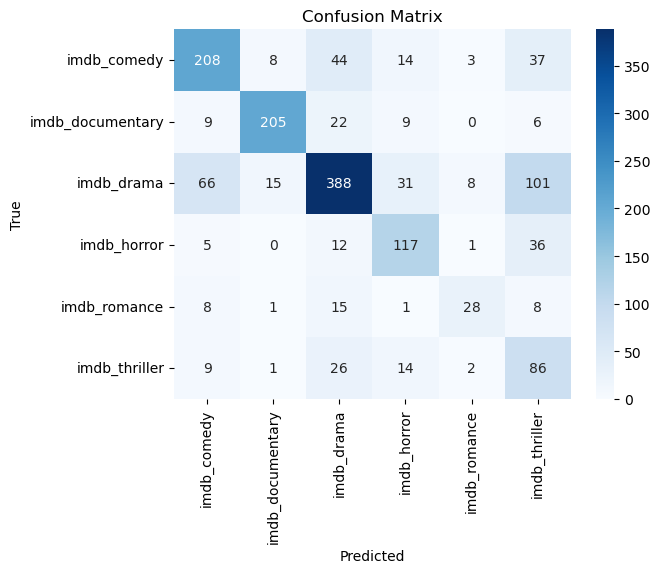

In [19]:
test(dataloader_test,model,loss_fnc,encoder)